<a href="https://colab.research.google.com/github/Elsacred02/assignment_3_advanced_machine_learning/blob/main/Assignment3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Import dependencies

In [ ]:
# Import dependencies
import numpy as np
from tensorflow import keras
from tensorflow.keras import layers
import tensorflow as tf

# set seed
keras.utils.set_random_seed(42)


# Dataset

## The MNIST dataset

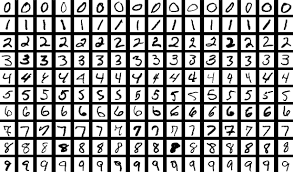

The MNIST dataset is an acronym that stands for the Modified National Institute of Standards and Technology dataset.

It is a dataset of 60,000 small square 28×28 pixel grayscale images of handwritten single digits between 0 and 9.

The task is to classify a given image of a handwritten digit into one of 10 classes representing integer values from 0 to 9, inclusively.

In [ ]:
# load the data and divide it into train/test split
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()
print(x_train.shape, y_train.shape)
print(x_test.shape, y_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
(60000, 28, 28) (60000,)
(10000, 28, 28) (10000,)


Let's visualize the first row of the training set to see how it appears.

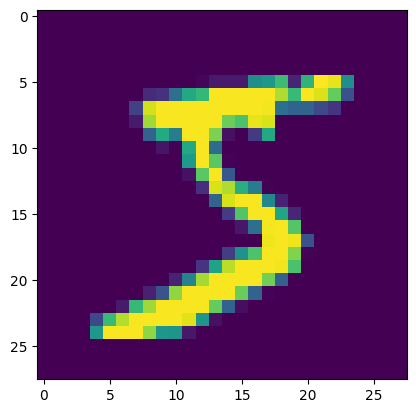

Label: 5


In [ ]:
# Show the first element
import matplotlib.pyplot as plt
plt.imshow(x_train[0])
plt.show()
print(f"Label: {y_train[0]}")



### Data preparation

We now normalize the images of the dataset so that their range is between 0 and 1

In [ ]:
# Scale images into the [0 1] range
x_train = x_train.astype("float32") / 255
x_test = x_test.astype("float32") / 255

# Make images with size (28,28,1)
x_train = np.expand_dims(x_train, -1)
x_test = np.expand_dims(x_test, -1)

# check shape
print(x_train.shape, x_test.shape)

(60000, 28, 28, 1) (10000, 28, 28, 1)


For multi-class problems, we need to convert the label representing the class into a one-hot vector.

In [ ]:
# convert class array into one-hot representation
num_classes = 10
y_train = keras.utils.to_categorical(y_train, num_classes)
y_test = keras.utils.to_categorical(y_test, num_classes)

# we have seen this class is 5
print(y_train.shape)
print(y_train[0])

(60000, 10)
[0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]


# Model definition

In order to define the CNN for our classification problem, we use:

- Convolutional layers
- Pooling layers
- Fully-connected layers

## Convolutional layer

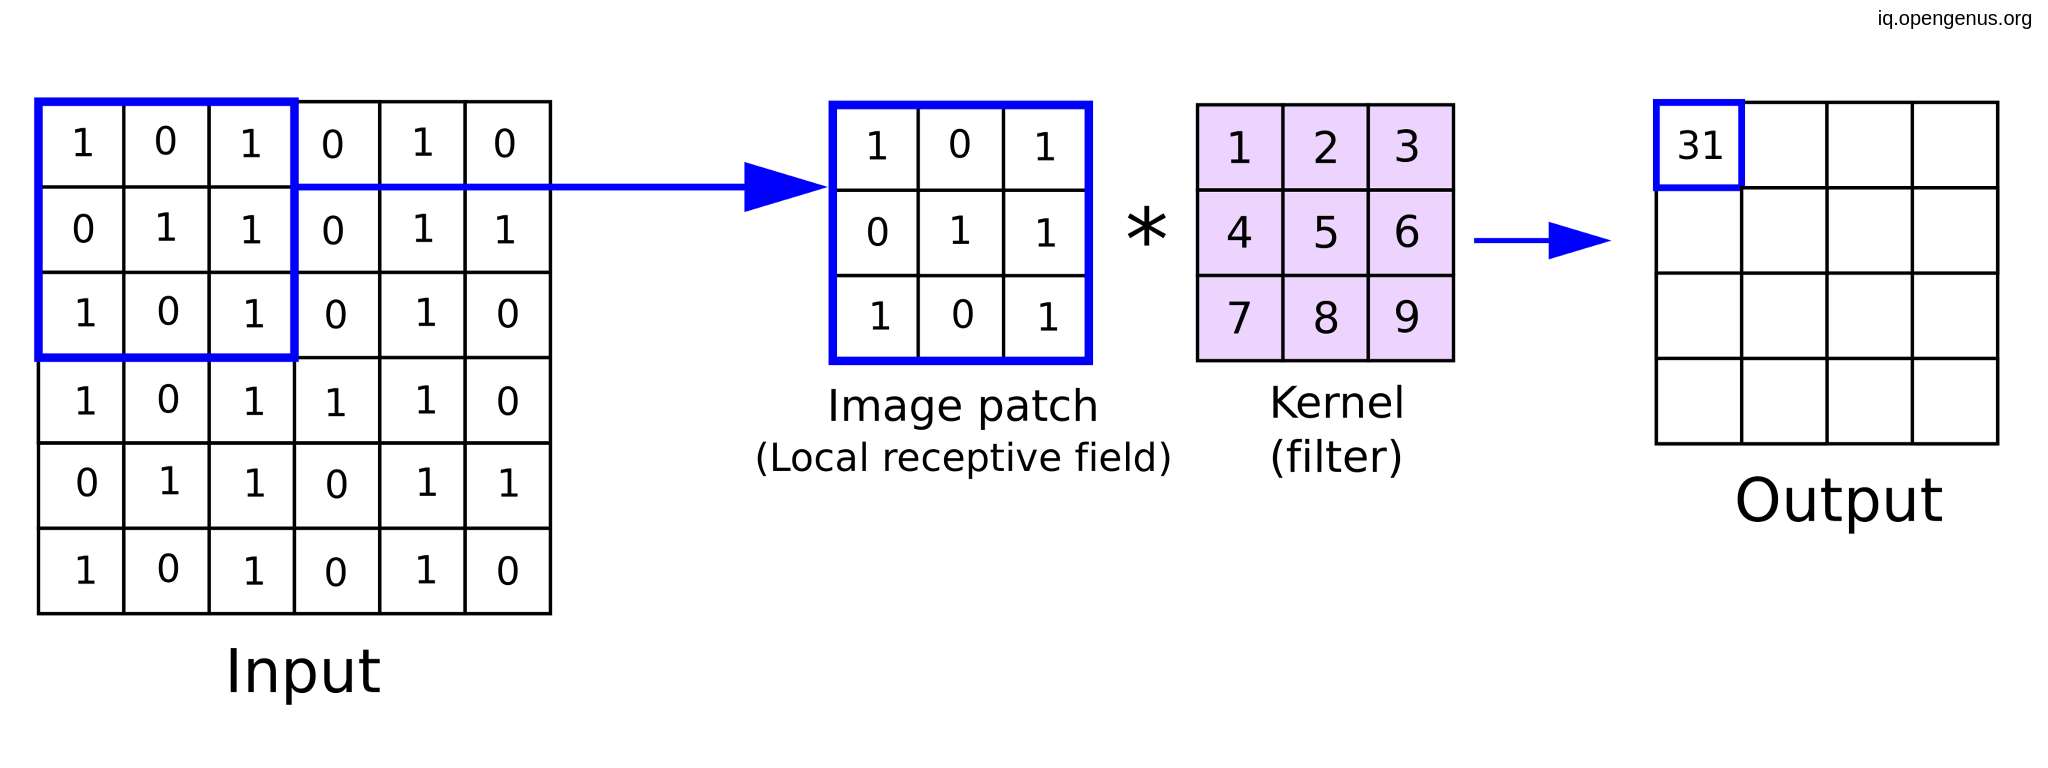

## Pooling layers

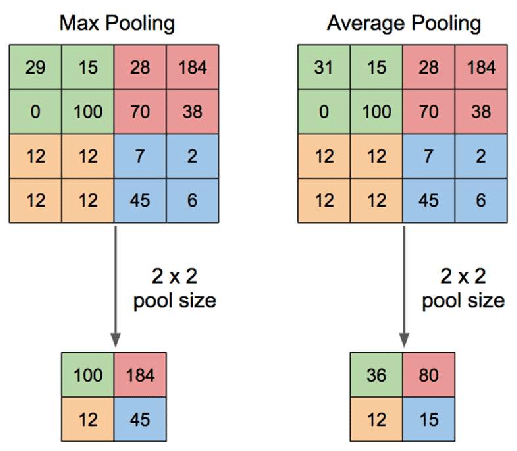

In [ ]:
# Model/data parameters
num_classes = 10
input_shape = (28,28,1)

model = keras.Sequential(
    [
      keras.Input(shape=input_shape),
      layers.Conv2D(32, kernel_size=3, activation="relu"),
      layers.MaxPool2D(pool_size=2),
      layers.Conv2D(64, kernel_size=3, activation="relu"),
      layers.MaxPool2D(pool_size=2),
      layers.Flatten(),
      layers.Dropout(0.5),
      layers.Dense(num_classes, activation="softmax")
    ]
)
model.summary()

# input HxWx32
# 64 kernels 3x3x32x64+64



Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │        16,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,826 (136.04 KB)

 Trainable params: 34,826 (136.04 KB)

 Non-trainable params: 0 (0.00 B)

# Training

Let's train our model! For this, we need to specify the loss function we want to optimize. A common choice is the [categorical cross-entropy loss](https://keras.io/api/losses/probabilistic_losses/#categoricalcrossentropy-class). In addition, we monitor the accuracy to check the performance of our model.

In [ ]:
from sklearn import metrics
batch_size = 128
epochs = 5

model.compile(loss="categorical_crossentropy", optimizer="adam", metrics=["accuracy"])
history = model.fit(x_train, y_train, batch_size=batch_size, epochs=epochs, validation_split=0.2)

Epoch 1/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 0.7503 - loss: 0.8371 - val_accuracy: 0.9716 - val_loss: 0.1011
Epoch 2/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9607 - loss: 0.1298 - val_accuracy: 0.9806 - val_loss: 0.0682
Epoch 3/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9716 - loss: 0.0931 - val_accuracy: 0.9843 - val_loss: 0.0552
Epoch 4/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9768 - loss: 0.0770 - val_accuracy: 0.9859 - val_loss: 0.0500
Epoch 5/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9793 - loss: 0.0676 - val_accuracy: 0.9870 - val_loss: 0.0447


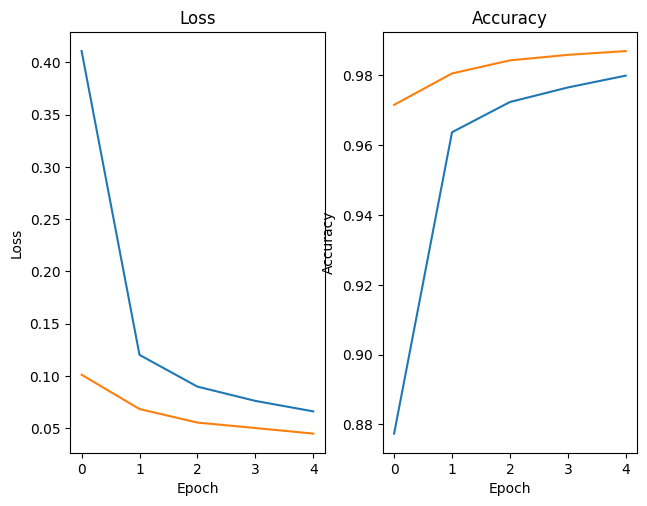

In [ ]:
def plot_performance(history):
  fig, ax = plt.subplots(1, 2)
  fig.tight_layout()
  train_acc = history.history['accuracy']
  valid_acc = history.history['val_accuracy']
  train_loss = history.history['loss']
  valid_loss = history.history['val_loss']
  ax[0].set_xlabel('Epoch')
  ax[0].set_ylabel('Loss')
  ax[0].set_title('Loss')
  ax[0].plot(train_loss)
  ax[0].plot(valid_loss)
  ax[1].set_title('Accuracy')
  ax[1].set_xlabel('Epoch')
  ax[1].set_ylabel('Accuracy')
  ax[1].plot(train_acc)
  ax[1].plot(valid_acc)
  plt.show()

plot_performance(history)


# Evaluation

Let's see the performance we obtain on the test set.

In [ ]:
score = model.evaluate(x_test, y_test, verbose=0)
print("Test loss", score[0])
print("Test accuracy", score[1])

Test loss 0.03703739494085312
Test accuracy 0.9886999726295471
